# Notebook 2: Reducción de Dimensionalidad

## Proyecto: Análisis de Perfiles Operativos en Cliente Industrial

**Objetivo:** Aplicar técnicas de reducción de dimensionalidad (PCA y UMAP) para transformar el espacio de 47 variables a representaciones de menor dimensión, facilitando la visualización y el análisis de patrones operativos.

**Entrada:** Datos normalizados del Notebook 1 (`processed_data_scaled.csv`)

---

### Contenido del Notebook

1. **Configuración del Entorno**
2. **Carga de Datos Procesados**
3. **Análisis de Componentes Principales (PCA)**
4. **Reducción No Lineal con UMAP**
5. **Análisis Comparativo PCA vs UMAP**
6. **Interpretación de Componentes y Proyecciones**
7. **Exportación de Datos Reducidos**

## 1. Configuración del Entorno

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import pickle
from pathlib import Path
import warnings

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Machine Learning - Reducción de dimensionalidad
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# Métricas
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform

# Configuración
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("Librerías importadas exitosamente")

✓ Librerías importadas exitosamente


## 2. Carga de Datos Procesados

In [ ]:
# Cargar datos escalados
data_path = Path.cwd().parent / 'data' / 'processed_data_scaled.csv'
df = pd.read_csv(data_path)

# Cargar datos con features originales para contexto
data_featured_path = Path.cwd().parent / 'data' / 'processed_data_featured.csv'
df_featured = pd.read_csv(data_featured_path)

# Separar features numéricas de columnas contextuales
context_cols = ['FECHA', 'HORA', 'INTERVALO', 'CATEGORIA']
feature_cols = [col for col in df.columns if col not in context_cols]

X = df[feature_cols].values
print(f"Datos cargados exitosamente")
print(f"  Dimensiones: {X.shape[0]:,} observaciones × {X.shape[1]} features")
print(f"  Features para reducción: {len(feature_cols)}")
print(f"  Columnas contextuales: {len(context_cols)}")

✓ Datos cargados exitosamente
  Dimensiones: 2,881 observaciones × 46 features
  Features para reducción: 46
  Columnas contextuales: 4


## 3. Análisis de Componentes Principales (PCA)

PCA es una técnica lineal que busca las direcciones de máxima varianza en los datos.

In [ ]:
# Aplicar PCA para obtener todos los componentes
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X)

# Calcular varianza explicada acumulada
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Encontrar número de componentes para 90%, 95%, 99% de varianza
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_99 = np.argmax(cumulative_variance >= 0.99) + 1

print("PCA completo ejecutado")
print(f"\nVarianza explicada por componentes:")
print(f"  90% de varianza → {n_components_90} componentes")
print(f"  95% de varianza → {n_components_95} componentes")
print(f"  99% de varianza → {n_components_99} componentes")
print(f"\nPrimeros 5 componentes explican: {cumulative_variance[4]:.2%} de la varianza")

✓ PCA completo ejecutado

Varianza explicada por componentes:
  90% de varianza → 8 componentes
  95% de varianza → 11 componentes
  99% de varianza → 16 componentes

Primeros 5 componentes explican: 82.87% de la varianza


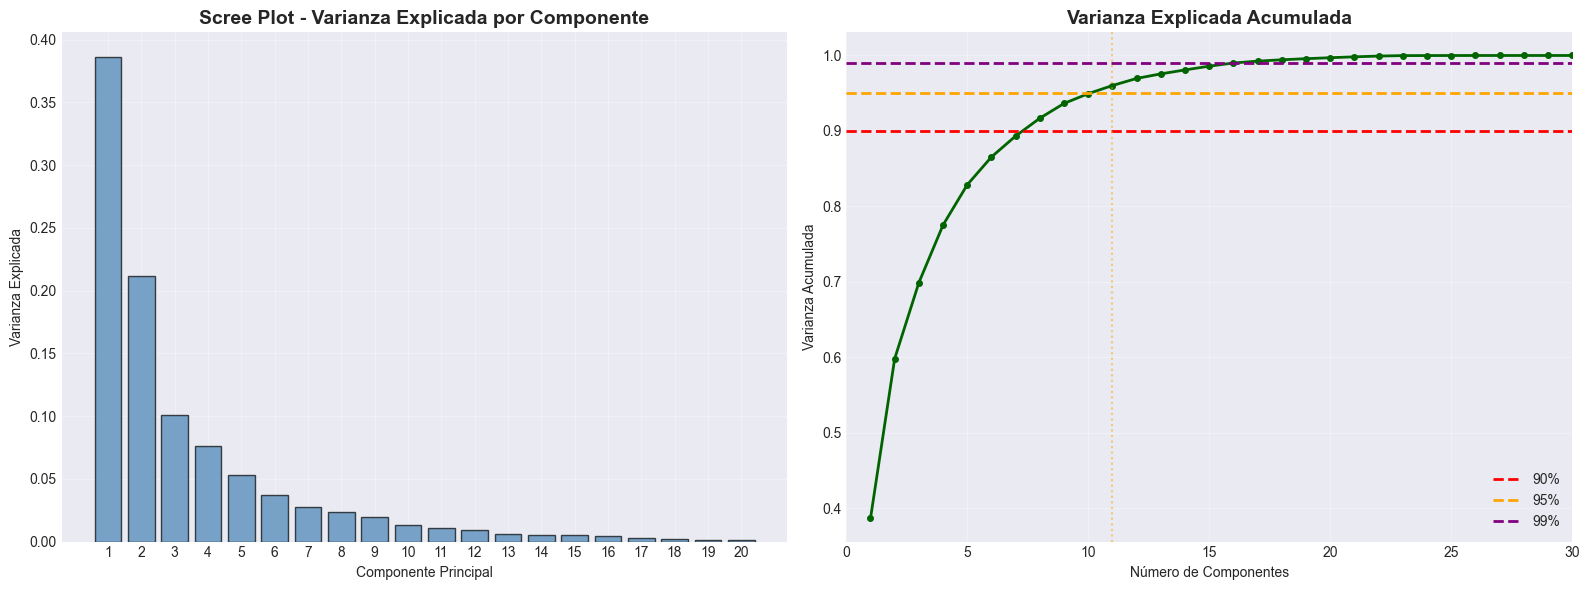

✓ El codo del scree plot sugiere retener ~11 componentes


In [ ]:
# Visualizar Scree Plot y varianza acumulada
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scree plot
axes[0].bar(range(1, min(21, len(explained_variance)+1)), 
           explained_variance[:20], 
           alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_title('Scree Plot - Varianza Explicada por Componente', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(1, 21))

# Varianza acumulada
axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance, 
            marker='o', linewidth=2, markersize=4, color='darkgreen')
axes[1].axhline(y=0.90, color='red', linestyle='--', label='90%', linewidth=2)
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95%', linewidth=2)
axes[1].axhline(y=0.99, color='purple', linestyle='--', label='99%', linewidth=2)
axes[1].axvline(x=n_components_95, color='orange', linestyle=':', alpha=0.5)
axes[1].set_title('Varianza Explicada Acumulada', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Acumulada')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, min(30, len(cumulative_variance)))

plt.tight_layout()
plt.show()

print(f"El codo del scree plot sugiere retener ~{n_components_95} componentes")

In [ ]:
# Aplicar PCA con 2 y 3 componentes para visualización
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X)

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X)

print(f"PCA 2D - Varianza explicada: {pca_2d.explained_variance_ratio_.sum():.2%}")
print(f"  PC1: {pca_2d.explained_variance_ratio_[0]:.2%}")
print(f"  PC2: {pca_2d.explained_variance_ratio_[1]:.2%}")

print(f"\nPCA 3D - Varianza explicada: {pca_3d.explained_variance_ratio_.sum():.2%}")
print(f"  PC1: {pca_3d.explained_variance_ratio_[0]:.2%}")
print(f"  PC2: {pca_3d.explained_variance_ratio_[1]:.2%}")
print(f"  PC3: {pca_3d.explained_variance_ratio_[2]:.2%}")

✓ PCA 2D - Varianza explicada: 59.83%
  PC1: 38.65%
  PC2: 21.18%

✓ PCA 3D - Varianza explicada: 69.90%
  PC1: 38.65%
  PC2: 21.18%
  PC3: 10.07%


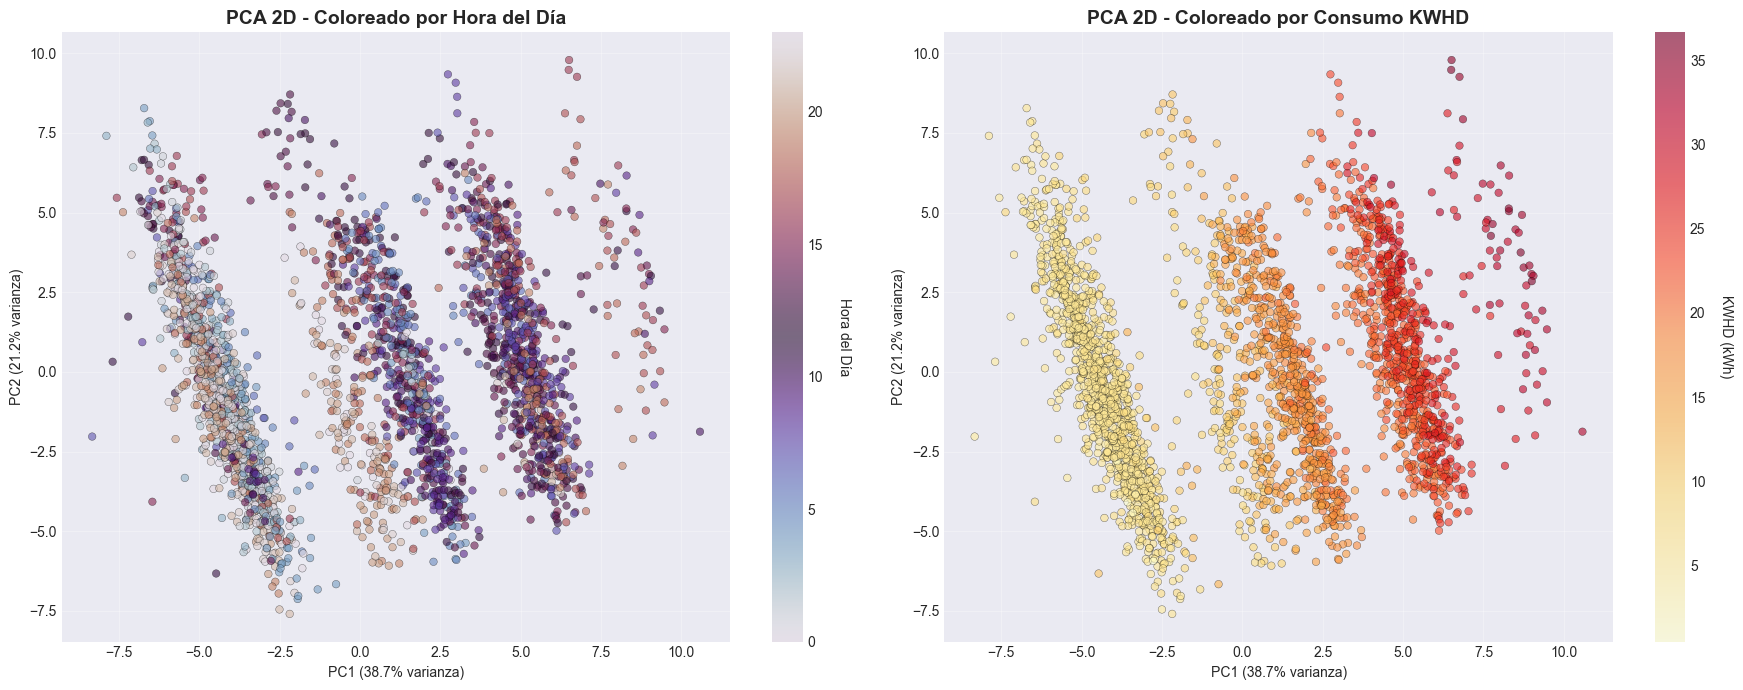

In [6]:
# Visualización PCA 2D coloreado por hora del día
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Colorear por hora
scatter1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                          c=df['HORA'], cmap='twilight', 
                          alpha=0.6, s=30, edgecolors='black', linewidths=0.3)
axes[0].set_title('PCA 2D - Coloreado por Hora del Día', fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} varianza)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} varianza)')
axes[0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Hora del Día', rotation=270, labelpad=20)

# Colorear por consumo (KWHD)
scatter2 = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                          c=df_featured['KWHD'], cmap='YlOrRd', 
                          alpha=0.6, s=30, edgecolors='black', linewidths=0.3)
axes[1].set_title('PCA 2D - Coloreado por Consumo KWHD', fontsize=14, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} varianza)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} varianza)')
axes[1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('KWHD (kWh)', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

## 4. Reducción No Lineal con UMAP

UMAP (Uniform Manifold Approximation and Projection) es una técnica no lineal que preserva tanto la estructura local como global de los datos.

In [7]:
# Aplicar UMAP 2D
print("Ejecutando UMAP 2D (esto puede tomar algunos minutos)...")
umap_2d = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap_2d = umap_2d.fit_transform(X)
print("✓ UMAP 2D completado")

# Aplicar UMAP 3D
print("\nEjecutando UMAP 3D...")
umap_3d = umap.UMAP(n_components=3, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap_3d = umap_3d.fit_transform(X)
print("✓ UMAP 3D completado")

Ejecutando UMAP 2D (esto puede tomar algunos minutos)...
✓ UMAP 2D completado

Ejecutando UMAP 3D...
✓ UMAP 3D completado


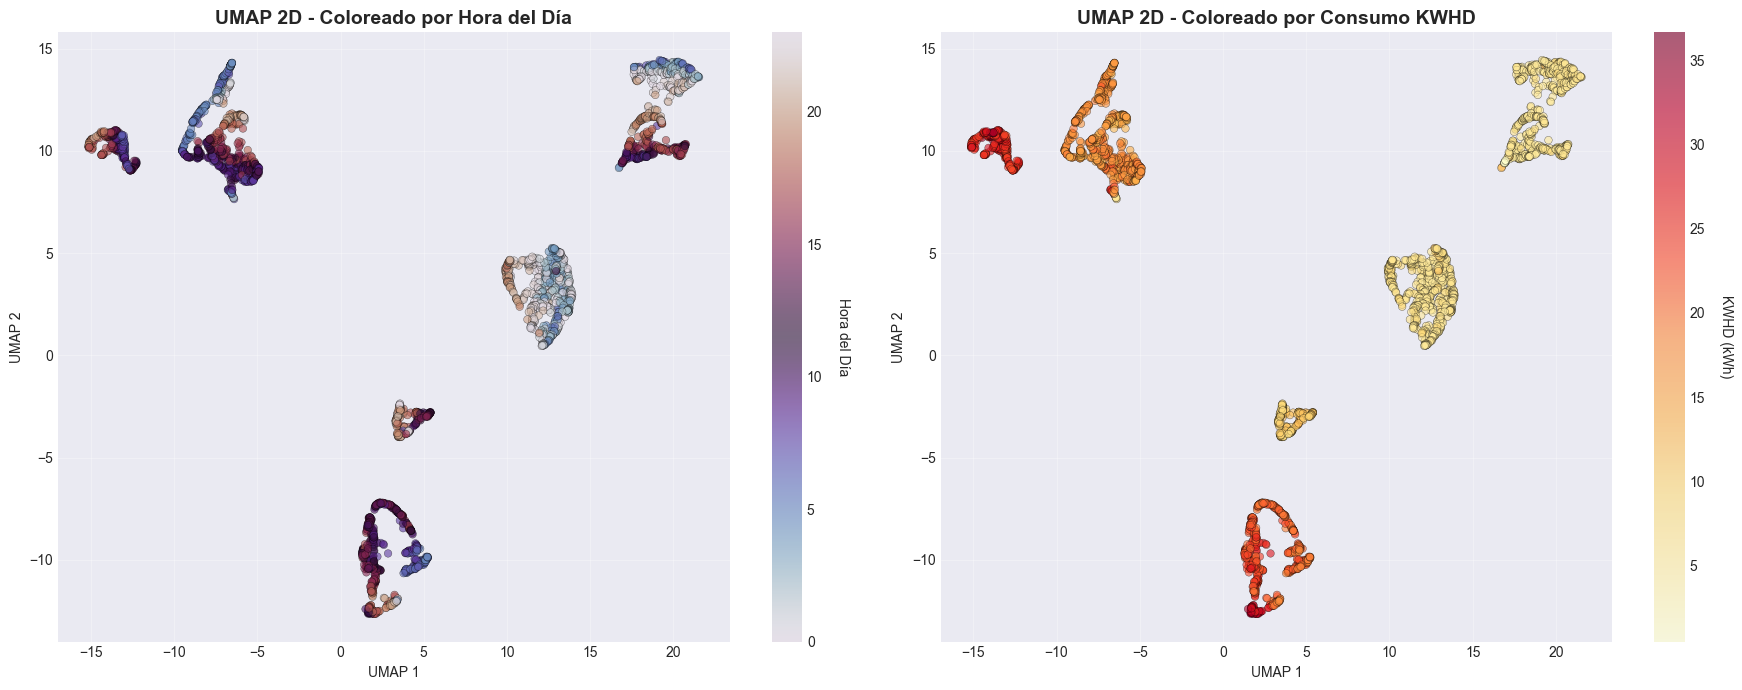

In [8]:
# Visualización UMAP 2D
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Colorear por hora
scatter1 = axes[0].scatter(X_umap_2d[:, 0], X_umap_2d[:, 1], 
                          c=df['HORA'], cmap='twilight', 
                          alpha=0.6, s=30, edgecolors='black', linewidths=0.3)
axes[0].set_title('UMAP 2D - Coloreado por Hora del Día', fontsize=14, fontweight='bold')
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')
axes[0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Hora del Día', rotation=270, labelpad=20)

# Colorear por consumo
scatter2 = axes[1].scatter(X_umap_2d[:, 0], X_umap_2d[:, 1], 
                          c=df_featured['KWHD'], cmap='YlOrRd', 
                          alpha=0.6, s=30, edgecolors='black', linewidths=0.3)
axes[1].set_title('UMAP 2D - Coloreado por Consumo KWHD', fontsize=14, fontweight='bold')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
axes[1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('KWHD (kWh)', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

## 5. Análisis Comparativo PCA vs UMAP

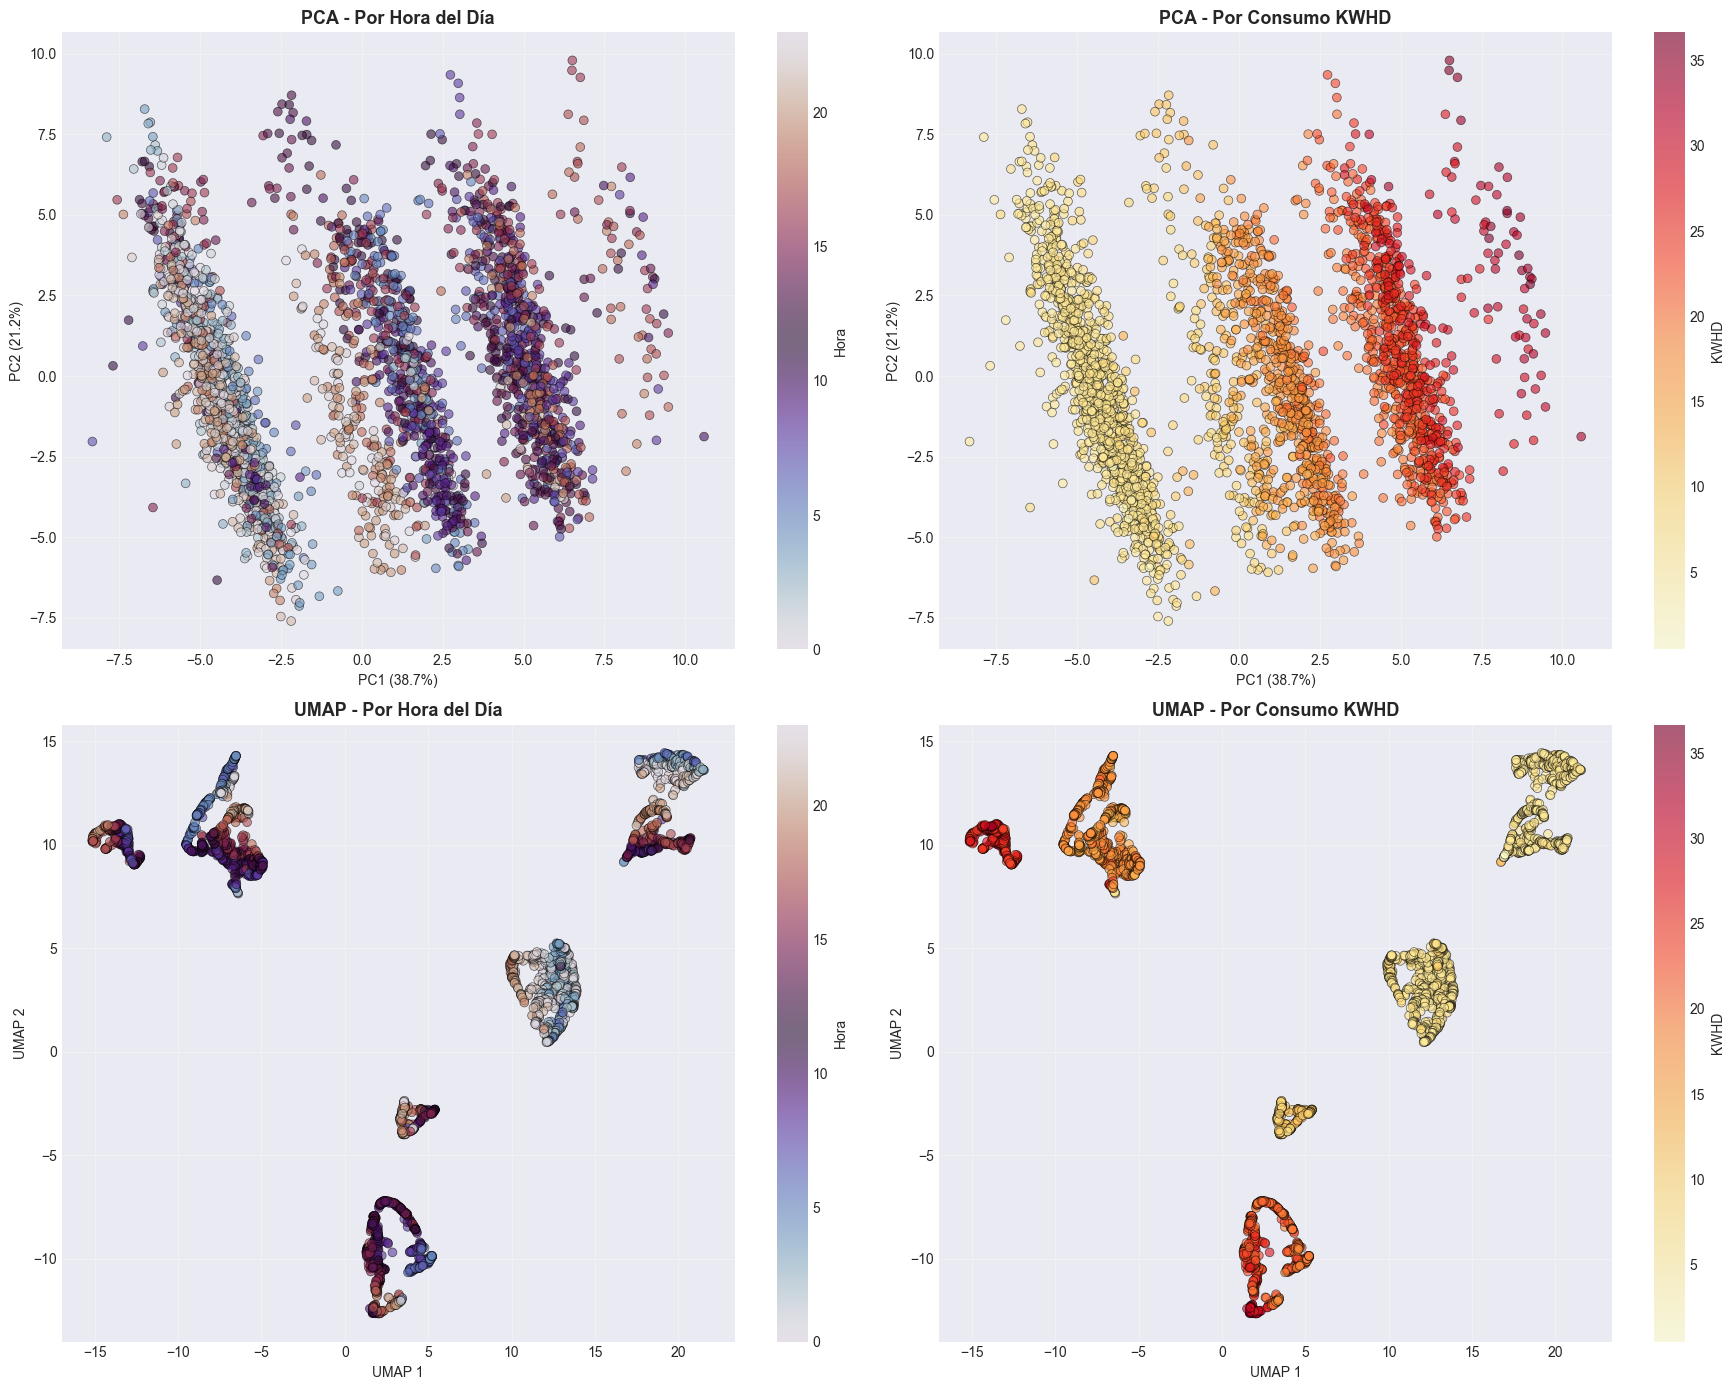

In [9]:
# Comparación lado a lado
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# PCA - Hora
scatter1 = axes[0, 0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                             c=df['HORA'], cmap='twilight', 
                             alpha=0.6, s=40, edgecolors='black', linewidths=0.5)
axes[0, 0].set_title('PCA - Por Hora del Día', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
axes[0, 0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
axes[0, 0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0, 0], label='Hora')

# PCA - Consumo
scatter2 = axes[0, 1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                             c=df_featured['KWHD'], cmap='YlOrRd', 
                             alpha=0.6, s=40, edgecolors='black', linewidths=0.5)
axes[0, 1].set_title('PCA - Por Consumo KWHD', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
axes[0, 1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
axes[0, 1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[0, 1], label='KWHD')

# UMAP - Hora
scatter3 = axes[1, 0].scatter(X_umap_2d[:, 0], X_umap_2d[:, 1], 
                             c=df['HORA'], cmap='twilight', 
                             alpha=0.6, s=40, edgecolors='black', linewidths=0.5)
axes[1, 0].set_title('UMAP - Por Hora del Día', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('UMAP 1')
axes[1, 0].set_ylabel('UMAP 2')
axes[1, 0].grid(True, alpha=0.3)
plt.colorbar(scatter3, ax=axes[1, 0], label='Hora')

# UMAP - Consumo
scatter4 = axes[1, 1].scatter(X_umap_2d[:, 0], X_umap_2d[:, 1], 
                             c=df_featured['KWHD'], cmap='YlOrRd', 
                             alpha=0.6, s=40, edgecolors='black', linewidths=0.5)
axes[1, 1].set_title('UMAP - Por Consumo KWHD', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('UMAP 1')
axes[1, 1].set_ylabel('UMAP 2')
axes[1, 1].grid(True, alpha=0.3)
plt.colorbar(scatter4, ax=axes[1, 1], label='KWHD')

plt.tight_layout()
plt.show()

## 6. Interpretación de Componentes Principales

Analizamos qué variables originales contribuyen más a cada componente principal.

In [10]:
# Obtener loadings de los primeros 3 componentes
loadings = pca_3d.components_.T * np.sqrt(pca_3d.explained_variance_)
loadings_df = pd.DataFrame(
    loadings,
    columns=['PC1', 'PC2', 'PC3'],
    index=feature_cols
)

# Top 10 variables por componente
print("="*80)
print("INTERPRETACIÓN DE COMPONENTES PRINCIPALES")
print("="*80)

for i, pc in enumerate(['PC1', 'PC2', 'PC3']):
    print(f"\n{pc} ({pca_3d.explained_variance_ratio_[i]:.2%} de varianza):")
    print("-" * 40)
    top_positive = loadings_df[pc].nlargest(5)
    top_negative = loadings_df[pc].nsmallest(5)
    
    print("  Variables con mayor contribución positiva:")
    for var, val in top_positive.items():
        print(f"    • {var}: {val:.3f}")
    
    print("\n  Variables con mayor contribución negativa:")
    for var, val in top_negative.items():
        print(f"    • {var}: {val:.3f}")

INTERPRETACIÓN DE COMPONENTES PRINCIPALES

PC1 (38.65% de varianza):
----------------------------------------
  Variables con mayor contribución positiva:
    • CORRIENTE_PROM: 0.957
    • CORRIENTE_MEDIA: 0.957
    • KWHD: 0.951
    • KWD: 0.951
    • KVAD: 0.950

  Variables con mayor contribución negativa:
    • THD_CORRIENTE_FASE_C: -0.878
    • THD_CORRIENTE_FASE_A: -0.866
    • THD_CORRIENTE_PROMEDIO: -0.860
    • THD_CORRIENTE_FASE_B: -0.690
    • HORA_COS: -0.540

PC2 (21.18% de varianza):
----------------------------------------
  Variables con mayor contribución positiva:
    • VOLTAJE_MEDIO: 0.930
    • VOLTAJE_PROM: 0.930
    • VA: 0.930
    • VB: 0.929
    • VB_DESV: 0.929

  Variables con mayor contribución negativa:
    • DESBALANCE_VOLTAJE: -0.304
    • HORA_COS: -0.267
    • VOLTAJE_STD: -0.254
    • THD_VOLT_FASE_B: -0.124
    • THD_VOLT_FASE_C: -0.097

PC3 (10.07% de varianza):
----------------------------------------
  Variables con mayor contribución positiva:
    

## 7. Exportación de Datos Reducidos

In [ ]:
# Crear DataFrames con datos reducidos
pca_2d_df = pd.DataFrame(
    X_pca_2d,
    columns=['PC1', 'PC2']
)
pca_2d_df['FECHA'] = df['FECHA'].values
pca_2d_df['HORA'] = df['HORA'].values
pca_2d_df['KWHD'] = df_featured['KWHD'].values

pca_3d_df = pd.DataFrame(
    X_pca_3d,
    columns=['PC1', 'PC2', 'PC3']
)
pca_3d_df['FECHA'] = df['FECHA'].values
pca_3d_df['HORA'] = df['HORA'].values
pca_3d_df['KWHD'] = df_featured['KWHD'].values

umap_2d_df = pd.DataFrame(
    X_umap_2d,
    columns=['UMAP1', 'UMAP2']
)
umap_2d_df['FECHA'] = df['FECHA'].values
umap_2d_df['HORA'] = df['HORA'].values
umap_2d_df['KWHD'] = df_featured['KWHD'].values

umap_3d_df = pd.DataFrame(
    X_umap_3d,
    columns=['UMAP1', 'UMAP2', 'UMAP3']
)
umap_3d_df['FECHA'] = df['FECHA'].values
umap_3d_df['HORA'] = df['HORA'].values
umap_3d_df['KWHD'] = df_featured['KWHD'].values

# Guardar en data/
pca_2d_df.to_csv('../data/pca_2d.csv', index=False)
pca_3d_df.to_csv('../data/pca_3d.csv', index=False)
umap_2d_df.to_csv('../data/umap_2d.csv', index=False)
umap_3d_df.to_csv('../data/umap_3d.csv', index=False)

print("Datos exportados:")
print(f"  • PCA 2D: {pca_2d_df.shape}")
print(f"  • PCA 3D: {pca_3d_df.shape}")
print(f"  • UMAP 2D: {umap_2d_df.shape}")
print(f"  • UMAP 3D: {umap_3d_df.shape}")

✓ Datos exportados:
  • PCA 2D: (2881, 5)
  • PCA 3D: (2881, 6)
  • UMAP 2D: (2881, 5)
  • UMAP 3D: (2881, 6)


## 8. Conclusiones del Análisis de Reducción de Dimensionalidad

### Resumen de Resultados

**PCA (Principal Component Analysis):**
- Técnica lineal que maximiza la varianza explicada
- Interpretable mediante loadings de componentes principales
- Útil para identificar variables que más contribuyen a la variabilidad

**UMAP (Uniform Manifold Approximation and Projection):**
- Técnica no lineal que preserva estructura local y global
- Mayor capacidad para revelar patrones complejos y no lineales
- Genera agrupaciones más compactas y separadas visualmente

### Datos Preparados

Los datos reducidos están disponibles en formato 2D y 3D para las siguientes fases:
- Aplicación de algoritmos de clustering
- Validación con métricas de calidad
- Visualización de resultados